# Week 2 Advanced Analytics


## 1. Objective

- Build time-series revenue metrics and Month-over-Month growth.
- Analyze repeat buyers, customer value tiers, and active lifespan.
- Create market-level aggregation and a Country x Month pivot table.
- Produce two initial visualizations for Week 3 reporting.

In [1]:
# 这里先统一导入本周会用到的包。
# pandas / numpy 负责数据分析，matplotlib / seaborn 负责画图，pathlib 负责管理路径。
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 显示设置：表格不要被截断得太厉害，方便检查字段和结果。
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 图表风格先统一设置，后面两张图会更干净。
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


## 2. Setup & Path Configuration

The notebook can run from the project root or the `week2` folder. Paths are detected with `pathlib` and relative project structure, without relying on a personal local path.

In [2]:
# 定位项目根目录
# -> 查找 Week 1 输出
# -> 创建 Week 2 输出目录
# -> 校验必要文件
CURRENT_DIR = Path.cwd().resolve()
REQUIRED_FILES = {
    'cleaned_sales': 'cleaned_sales.csv',
    'order_features': 'order_features.csv',
    'customer_features': 'customer_features.csv',
    'product_features': 'product_features.csv',
    'country_features': 'country_features.csv',
}

# 去重并保留顺序，避免重复搜索同一个目录。
def unique_paths(paths):
    unique = []
    seen = set()
    for path in paths:
        resolved = path.resolve()
        if resolved not in seen:
            unique.append(resolved)
            seen.add(resolved)
    return unique

# 从当前目录和父级目录推断项目根目录。
def build_project_root_candidates(current_dir):
    candidates = []
    for path in [current_dir, *current_dir.parents]:
        candidates.append(path)
        if path.name.lower() in {'week2', 'notebook', 'notebooks'}:
            candidates.append(path.parent)
        if path.parent.name.lower() in {'week2', 'notebook', 'notebooks'}:
            candidates.append(path.parent.parent)
    return unique_paths(candidates)

# 在常见相对目录中查找 Week 1 的清洗数据和特征表。
def build_search_dirs(project_root, current_dir):
    dataset_dirs = [
        project_root / 'week1总' / 'Week1_0706' / 'dataset',
        project_root / 'week1' / 'Week1_0706' / 'dataset',
        project_root / 'Week1_0706' / 'dataset',
        project_root / 'week1总' / 'dataset',
        project_root / 'week1' / 'dataset',
        project_root / 'data' / 'processed',
        project_root / 'dataset',
        project_root / 'week2' / 'data' / 'processed',
        project_root / 'week2' / 'dataset',
        current_dir / 'data' / 'processed',
        current_dir / 'dataset',
    ]
    feature_dirs = [
        project_root / 'week1总' / 'feature_tables',
        project_root / 'week1' / 'feature_tables',
        project_root / 'feature_tables',
        project_root / 'Week1_0706' / 'feature_tables',
        project_root / 'Week1_0706' / 'features',
        project_root / 'features',
        project_root / 'data' / 'processed',
        project_root / 'week2' / 'features',
        project_root / 'week2' / 'data' / 'processed',
        current_dir / 'features',
        current_dir / 'data' / 'processed',
    ]
    return unique_paths(dataset_dirs), unique_paths(feature_dirs)

# 给定一个项目根目录候选，尝试找到所有必需输入文件。
def find_required_inputs(project_root, current_dir):
    dataset_dirs, feature_dirs = build_search_dirs(project_root, current_dir)
    search_dirs_by_file = {
        'cleaned_sales': dataset_dirs,
        'order_features': feature_dirs,
        'customer_features': feature_dirs,
        'product_features': feature_dirs,
        'country_features': feature_dirs,
    }

    found_paths = {}
    searched_locations = []
    for key, filename in REQUIRED_FILES.items():
        for directory in search_dirs_by_file[key]:
            searched_locations.append(directory)
            candidate = directory / filename
            if candidate.exists():
                found_paths[key] = candidate
                break
    return found_paths, unique_paths(searched_locations)

# 计算一组路径的公共父目录，用来标记 Week 1 输入根目录。
def common_parent(paths):
    candidate = paths[0].parent
    while candidate != candidate.parent:
        if all(candidate == path or candidate in path.parents for path in paths):
            return candidate
        candidate = candidate.parent
    return candidate

project_root_candidates = build_project_root_candidates(CURRENT_DIR)
file_paths = None
searched_locations = []
PROJECT_ROOT = None

for candidate_root in project_root_candidates:
    candidate_paths, candidate_locations = find_required_inputs(candidate_root, CURRENT_DIR)
    searched_locations.extend(candidate_locations)
    if set(candidate_paths) == set(REQUIRED_FILES):
        PROJECT_ROOT = candidate_root
        file_paths = candidate_paths
        break

if file_paths is None:
    unique_locations = unique_paths(searched_locations)
    location_text = '\n'.join(f'- {location}' for location in unique_locations[:30])
    raise FileNotFoundError(
        'Missing required Week 1 output files.\n'
        f'Required files: {list(REQUIRED_FILES.values())}\n'
        f'Current working directory: {CURRENT_DIR}\n'
        'Please run this notebook from the project root or the week2 folder, '
        'and keep Week 1 outputs under week1总/, week1/, Week1_0706/, data/processed/, or features/.\n'
        f'Searched locations:\n{location_text}'
    )

# Week 1 输入只读；Week 2 输出按类型分开保存。
WEEK1_ROOT = common_parent(list(file_paths.values()))
DATASET_DIR = file_paths['cleaned_sales'].parent
FEATURE_DIR = common_parent([
    file_paths['order_features'],
    file_paths['customer_features'],
    file_paths['product_features'],
    file_paths['country_features'],
])
WEEK2_ROOT = PROJECT_ROOT / 'week2' if (PROJECT_ROOT / 'week2').exists() else PROJECT_ROOT
OUTPUT_ROOT = WEEK2_ROOT / 'outputs'
FORM_OUTPUT_DIR = OUTPUT_ROOT / 'forms'
PLOT_OUTPUT_DIR = OUTPUT_ROOT / 'plots'
FORM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_files = [name for name, path in file_paths.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f'Missing required input files: {missing_files}. '
        f'Current working directory: {CURRENT_DIR}'
    )

# 用相对路径打印，方便 GitHub reviewer 理解项目结构。
def display_path(path):
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path

print(f'Project root detected: {display_path(PROJECT_ROOT)}')
print(f'Week 1 input root: {display_path(WEEK1_ROOT)}')
print(f'Week 2 form output folder: {display_path(FORM_OUTPUT_DIR)}')
print(f'Week 2 plot output folder: {display_path(PLOT_OUTPUT_DIR)}')


Project root detected: .
Week 1 input root: week1
Week 2 form output folder: week2/outputs/forms
Week 2 plot output folder: week2/outputs/plots


## 3. Load Week 1 Outputs

Customer IDs and invoice IDs are identifiers, not numeric measures. They are loaded as strings to avoid unnecessary casting.

In [3]:
# 这里读取 Week 1 的清洗后交易明细表。
# 本周直接基于 Week 1 干净数据继续分析。
# CustomerID / InvoiceNo 属于编号字段，更适合直接读成 string。
# OrderDate 在 CSV 里会变回字符串，这里读入时转成 datetime，后面才能按天和按月分析。
cleaned_sales = pd.read_csv(
    file_paths['cleaned_sales'],
    dtype={'CustomerID': 'string', 'InvoiceNo': 'string'},
    parse_dates=['OrderDate'],
)

# 订单特征表主要用于验证和上下文，不作为本周主要计算来源。
order_features = pd.read_csv(
    file_paths['order_features'],
    dtype={'CustomerID': 'string', 'InvoiceNo': 'string'},
    parse_dates=['OrderDate'],
)

# 客户特征表用于复购率、客户分层和活跃天数分析。
customer_features = pd.read_csv(
    file_paths['customer_features'],
    dtype={'CustomerID': 'string'},
    parse_dates=['customer_first_order_date', 'customer_last_order_date'],
)

# 商品和国家特征表用于验证和市场分析。
product_features = pd.read_csv(
    file_paths['product_features'],
    parse_dates=['product_first_sold_date', 'product_last_sold_date'],
)

country_features = pd.read_csv(
    file_paths['country_features'],
    parse_dates=['country_first_order_date', 'country_last_order_date'],
)

# 简单看一下规模，确认读入的是 Week 1 的正式结果。
loaded_tables = pd.DataFrame({
    'table': ['cleaned_sales', 'order_features', 'customer_features', 'product_features', 'country_features'],
    'rows': [len(cleaned_sales), len(order_features), len(customer_features), len(product_features), len(country_features)],
    'columns': [cleaned_sales.shape[1], order_features.shape[1], customer_features.shape[1], product_features.shape[1], country_features.shape[1]],
})

display(loaded_tables)
display(cleaned_sales.head(3))


,table,rows,columns
0,cleaned_sales,392692,10
1,order_features,18532,10
2,customer_features,4338,13
3,product_features,3665,10
4,country_features,37,10


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,OrderDate,Revenue,OrderMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850,United Kingdom,2010-12-01 08:26:00,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850,United Kingdom,2010-12-01 08:26:00,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850,United Kingdom,2010-12-01 08:26:00,22.00,2010-12


## 4. Data Validation Before Analysis

This step checks whether the Week 2 required fields exist in the actual Week 1 files.

In [4]:
# 确认 PDF 要求和现有数据能对应上。
required_columns = {
    'cleaned_sales': ['OrderDate', 'OrderMonth', 'InvoiceNo', 'Revenue', 'CustomerID', 'Country'],
    'customer_features': ['CustomerID', 'customer_order_count', 'customer_total_revenue', 'customer_active_days'],
    'country_features': ['Country', 'country_total_revenue', 'country_order_count', 'country_customer_count'],
}

table_lookup = {
    'cleaned_sales': cleaned_sales,
    'customer_features': customer_features,
    'country_features': country_features,
}

validation_rows = []
for table_name, columns in required_columns.items():
    table = table_lookup[table_name]
    for column in columns:
        validation_rows.append({
            'table': table_name,
            'required_column': column,
            'exists': column in table.columns,
            'dtype': str(table[column].dtype) if column in table.columns else 'missing',
        })

validation_summary = pd.DataFrame(validation_rows)
display(validation_summary)

# 如果关键字段缺失，直接停止，避免后面静默算错。
if not validation_summary['exists'].all():
    missing = validation_summary.loc[~validation_summary['exists'], ['table', 'required_column']]
    raise ValueError(f'Missing required columns:\n{missing}')

# 字段映射表：把 PDF 里的分析口径和现有 CSV 字段对应起来。
field_mapping = pd.DataFrame([
    {'analysis_need': 'Order datetime', 'actual_field': 'OrderDate', 'source_table': 'cleaned_sales'},
    {'analysis_need': 'Monthly period', 'actual_field': 'OrderMonth', 'source_table': 'cleaned_sales'},
    {'analysis_need': 'Order ID', 'actual_field': 'InvoiceNo', 'source_table': 'cleaned_sales / order_features'},
    {'analysis_need': 'Line revenue', 'actual_field': 'Revenue', 'source_table': 'cleaned_sales'},
    {'analysis_need': 'Customer ID', 'actual_field': 'CustomerID', 'source_table': 'cleaned_sales / customer_features'},
    {'analysis_need': 'Repeat buyer order count', 'actual_field': 'customer_order_count', 'source_table': 'customer_features'},
    {'analysis_need': 'Customer spend / LTV proxy', 'actual_field': 'customer_total_revenue', 'source_table': 'customer_features'},
    {'analysis_need': 'Customer active lifespan', 'actual_field': 'customer_active_days', 'source_table': 'customer_features'},
    {'analysis_need': 'Market revenue', 'actual_field': 'country_total_revenue', 'source_table': 'country_features'},
])

display(field_mapping)


,table,required_column,exists,dtype
0,cleaned_sales,OrderDate,True,datetime64[us]
1,cleaned_sales,OrderMonth,True,str
2,cleaned_sales,InvoiceNo,True,string
3,cleaned_sales,Revenue,True,float64
4,cleaned_sales,CustomerID,True,string
5,cleaned_sales,Country,True,str
6,customer_features,CustomerID,True,string
7,customer_features,customer_order_count,True,int64
8,customer_features,customer_total_revenue,True,float64
9,customer_features,customer_active_days,True,int64


,analysis_need,actual_field,source_table
0,Order datetime,OrderDate,cleaned_sales
1,Monthly period,OrderMonth,cleaned_sales
2,Order ID,InvoiceNo,cleaned_sales / order_features
3,Line revenue,Revenue,cleaned_sales
4,Customer ID,CustomerID,cleaned_sales / customer_features
5,Repeat buyer order count,customer_order_count,customer_features
6,Customer spend / LTV proxy,customer_total_revenue,customer_features
7,Customer active lifespan,customer_active_days,customer_features
8,Market revenue,country_total_revenue,country_features


The required fields are present. The dataset does not include Category or Payment Method fields, so Week 2 analysis uses the available transaction, customer, product, and country dimensions.


## 5. Reusable Helper Functions

These functions keep formatting, growth calculation, and plotting consistent across the notebook.

In [5]:

'''
Reusable Helper Functions
-> Standardize currency formatting
-> Standardize growth-rate formatting
-> Standardize chart output

定义复用函数
-> 统一金额单位
-> 统一增长率格式
-> 统一图表输出
'''

def format_currency(value):
    if pd.isna(value):
        return 'N/A'
    absolute_value = abs(value)
    if absolute_value >= 1_000_000:
        return f'${value / 1_000_000:,.2f}M'
    if absolute_value >= 1_000:
        return f'${value / 1_000:,.1f}K'
    return f'${value:,.2f}'

# 固定用 M 展示，适合国家收入、月收入这类大金额。
def format_currency_m(value):
    if pd.isna(value):
        return 'N/A'
    return f'${value / 1_000_000:,.2f}M'

# 固定用 K 展示，适合 AOV、平均客户收入、增长额这类中等金额。
def format_currency_k(value):
    if pd.isna(value):
        return 'N/A'
    return f'${value / 1_000:,.2f}K'

# 增长率统一加符号，方便一眼区分上涨和下降。
def format_signed_percent(value, decimals=1):
    if pd.isna(value):
        return 'N/A'
    percentage = value * 100
    if abs(percentage) < 0.05:
        return f'{0:.{decimals}f}%'
    sign = '+' if percentage > 0 else ''
    return f'{sign}{percentage:.{decimals}f}%'

# y 轴金额格式化，默认用动态单位。
def currency_axis_formatter(value, _position):
    return format_currency(value)

# M 单位 y 轴格式化，专门用于长尾国家收入图。
def currency_m_axis_formatter(value, _position):
    return format_currency_m(value)

# 计算 MoM 增长，保留 raw numeric columns 方便后续计算。
def calculate_mom_growth(monthly_frame, revenue_col='monthly_revenue'):
    return monthly_frame.assign(
        mom_growth_rate=monthly_frame[revenue_col].pct_change(),
        mom_absolute_growth=monthly_frame[revenue_col].diff(),
    )

# 折线图：用于日收入和滚动平均。
def plot_line_chart(frame, x_col, y_cols, labels, title, y_label, output_path):
    fig, ax = plt.subplots(figsize=(13, 6))
    for y_col, label in zip(y_cols, labels):
        ax.plot(frame[x_col], frame[y_col], label=label, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(FuncFormatter(currency_axis_formatter))
    ax.legend()
    ax.tick_params(axis='x', rotation=35)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    return fig, ax

# 普通柱状图 fallback：broken axis 失败时保底使用。
def plot_bar_chart(frame, x_col, y_col, title, x_label, y_label, output_path):
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=frame, x=x_col, y=y_col, ax=ax, color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(FuncFormatter(currency_m_axis_formatter))
    ax.tick_params(axis='x', rotation=35)
    for patch, value in zip(ax.patches, frame[y_col]):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            format_currency_m(value),
            ha='center',
            va='bottom',
            fontsize=9,
        )
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    return fig, ax

# 断轴柱状图：解决第一名过高导致其他国家看不清的问题。
def plot_broken_axis_bar_chart(frame, x_col, y_col, title, output_path):
    x_labels = frame[x_col].tolist()
    values = frame[y_col].to_numpy()
    x_positions = np.arange(len(frame))

    max_value = values.max()
    second_value = np.partition(values, -2)[-2] if len(values) > 1 else max_value
    lower_limit = second_value * 1.35
    upper_min = max_value * 0.88
    upper_max = max_value * 1.08

    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(13, 7),
        gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05},
    )

    bar_color = '#4C78A8'
    ax_top.bar(x_positions, values, color=bar_color)
    ax_bottom.bar(x_positions, values, color=bar_color)

    ax_top.set_ylim(upper_min, upper_max)
    ax_bottom.set_ylim(0, lower_limit)

    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)
    ax_top.tick_params(labeltop=False, bottom=False)
    ax_bottom.xaxis.tick_bottom()

    diagonal_size = 0.012
    kwargs = dict(transform=ax_top.transAxes, color='black', clip_on=False, linewidth=1)
    ax_top.plot((-diagonal_size, +diagonal_size), (-diagonal_size, +diagonal_size), **kwargs)
    ax_top.plot((1 - diagonal_size, 1 + diagonal_size), (-diagonal_size, +diagonal_size), **kwargs)
    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-diagonal_size, +diagonal_size), (1 - diagonal_size, 1 + diagonal_size), **kwargs)
    ax_bottom.plot((1 - diagonal_size, 1 + diagonal_size), (1 - diagonal_size, 1 + diagonal_size), **kwargs)

    ax_top.set_title(title)
    ax_bottom.set_xlabel('Country')
    fig.text(0.04, 0.5, 'Revenue ($M)', va='center', rotation='vertical')
    ax_top.yaxis.set_major_formatter(FuncFormatter(currency_m_axis_formatter))
    ax_bottom.yaxis.set_major_formatter(FuncFormatter(currency_m_axis_formatter))
    ax_bottom.set_xticks(x_positions)
    ax_bottom.set_xticklabels(x_labels, rotation=35, ha='right')

    for x, value in zip(x_positions, values):
        target_ax = ax_top if value > lower_limit else ax_bottom
        y_offset = max_value * 0.01 if target_ax is ax_top else lower_limit * 0.025
        target_ax.text(x, value + y_offset, format_currency_m(value), ha='center', va='bottom', fontsize=9)

    fig.tight_layout(rect=(0.05, 0, 1, 1))
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    return fig, (ax_top, ax_bottom)

# 双轴图：柱子看月收入差值，折线看收入环比增长率。
def plot_monthly_revenue_growth_dual_axis(frame, output_path):
    # 只展示 2011 全年；2010-12 是起始月，不能形成完整环比视角。
    plot_frame = (
        frame
        .loc[frame['OrderMonth'].between('2011-01', '2011-12')]
        .sort_values('OrderMonth')
    )
    x_positions = np.arange(len(plot_frame))
    x_labels = plot_frame['OrderMonth'].tolist()
    revenue_diff = plot_frame['mom_absolute_growth'].fillna(0)
    growth_rate = (plot_frame['mom_growth_rate'] * 100).fillna(0)
    bar_colors = np.where(revenue_diff.ge(0), '#59A14F', '#E15759')

    fig, ax_left = plt.subplots(figsize=(12.2, 5.8))
    ax_left.bar(x_positions, revenue_diff, color=bar_colors, alpha=0.85, label='Revenue Difference')
    ax_left.set_title('Monthly Revenue Difference and MoM Growth Rate (2011)')
    ax_left.set_xlabel('Order Month')
    ax_left.set_ylabel('Revenue Difference vs Previous Month')
    ax_left.yaxis.set_major_formatter(FuncFormatter(currency_axis_formatter))
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(x_labels, rotation=35, ha='right')
    ax_left.set_xlim(-0.55, len(plot_frame) - 0.45)

    ax_right = ax_left.twinx()
    ax_right.plot(x_positions, growth_rate, color='#4C78A8', marker='o', linewidth=2.2, label='MoM Growth Rate')
    ax_right.set_ylabel('MoM Growth Rate')
    ax_right.yaxis.set_major_formatter(FuncFormatter(lambda value, _position: f'{value:.0f}%'))

    # 让左右两个 y 轴的 0 横线对齐，避免 0 附近出现两条线。
    left_min, left_max = revenue_diff.min(), revenue_diff.max()
    right_min, right_max = growth_rate.min(), growth_rate.max()
    left_abs = max(abs(left_min), abs(left_max)) * 1.12
    right_abs = max(abs(right_min), abs(right_max)) * 1.12
    ax_left.set_ylim(-left_abs, left_abs)
    ax_right.set_ylim(-right_abs, right_abs)
    ax_left.axhline(0, color='black', linewidth=1.1, zorder=3)

    # 只保留一套横向网格，避免双轴网格重叠。
    ax_right.grid(False)
    ax_left.grid(axis='y', alpha=0.35)

    left_handles, left_labels = ax_left.get_legend_handles_labels()
    right_handles, right_labels = ax_right.get_legend_handles_labels()
    ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc='upper left')

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0.08)
    return fig, (ax_left, ax_right)

# 颜色加深函数：用来模拟饼图侧面厚度。
def _darken_color(hex_color, factor=0.60):
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    dark_rgb = tuple(max(0, min(255, int(channel * factor))) for channel in rgb)
    return '#{:02x}{:02x}{:02x}'.format(*dark_rgb)

# 单个伪 3D 爆炸饼图：下层做厚度，上层做真实占比。
def plot_exploded_3d_pie(ax, values, labels, colors, title):
    values = np.asarray(values, dtype=float)
    total = values.sum()
    explode = np.full(len(values), 0.08)
    explode[values.argmax()] = 0.16
    side_colors = [_darken_color(color) for color in colors]

    # 下层稍微下移，形成截图里那种侧面厚度。
    ax.pie(
        values,
        colors=side_colors,
        startangle=95,
        radius=1.0,
        center=(0, -0.16),
        explode=explode,
        wedgeprops={'linewidth': 0.45, 'edgecolor': 'white'},
    )

    # 上层保留真实颜色、标签和少量阴影。
    wedges, texts = ax.pie(
        values,
        labels=[f'{label}\n{value / total:.1%}' for label, value in zip(labels, values)],
        colors=colors,
        startangle=95,
        radius=1.0,
        center=(0, 0),
        explode=explode,
        shadow=True,
        labeldistance=1.18,
        textprops={'fontsize': 9.5, 'color': '#222222'},
        wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'},
    )

    # 压缩 y 轴比例，做出侧面观察的椭圆效果。
    ax.set_aspect(0.58)
    ax.set_title(title, pad=18)
    ax.set_xlim(-1.55, 1.55)
    ax.set_ylim(-1.28, 1.12)
    ax.axis('off')
    return wedges

# 客户层级图：左边看客户数量占比，右边看收入贡献占比。
def plot_customer_tier_share_chart(tier_frame, output_path):
    tier_order = ['High Value', 'Medium Value', 'Low Value']
    tier_colors = {
        'High Value': '#4C78A8',
        'Medium Value': '#F2B447',
        'Low Value': '#E15759',
    }

    plot_frame = (
        tier_frame
        .assign(value_tier=tier_frame['value_tier'].astype(str))
        .set_index('value_tier')
        .loc[tier_order]
        .reset_index()
    )
    colors = [tier_colors[tier] for tier in plot_frame['value_tier']]

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.8))

    wedges = plot_exploded_3d_pie(
        axes[0],
        plot_frame['customer_count'],
        plot_frame['value_tier'],
        colors,
        'Customer Count Share',
    )
    plot_exploded_3d_pie(
        axes[1],
        plot_frame['total_revenue'],
        plot_frame['value_tier'],
        colors,
        'Revenue Share',
    )

    fig.legend(
        wedges,
        plot_frame['value_tier'],
        title='Customer Tier',
        loc='upper right',
        bbox_to_anchor=(1.01, 0.96),
    )
    fig.suptitle('Customer Tier Share: Count vs Revenue', y=1.02)
    fig.tight_layout(rect=(0, 0, 0.88, 0.94))
    fig.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0.08)
    return fig, axes


## 6. Time-Series & Trend Analysis

Daily metrics show short-term movement. Monthly metrics show business growth direction.

In [6]:

'''
Time-Series Analysis
-> Aggregate daily revenue and order count
-> Calculate 7-day rolling average
-> Calculate monthly MoM growth

构建时间序列
-> 按天汇总收入和订单数
-> 计算 7 日滚动平均
-> 计算月度环比增长
'''

# 按日期聚合，忽略订单时间中的小时和分钟。
daily_revenue = (
    cleaned_sales
    .assign(OrderDay=cleaned_sales['OrderDate'].dt.floor('D'))
    .groupby('OrderDay', as_index=False)
    .agg(
        daily_revenue=('Revenue', 'sum'),
        daily_unique_order_count=('InvoiceNo', 'nunique'),
    )
    .sort_values('OrderDay')
)

# 用 7 日滚动平均平滑日收入波动。
daily_revenue = daily_revenue.assign(
    daily_revenue_7d_avg=daily_revenue['daily_revenue'].rolling(window=7, min_periods=1).mean()
)

# 按月汇总收入，继续使用 Week 1 已生成的 OrderMonth。
monthly_revenue = (
    cleaned_sales
    .groupby('OrderMonth', as_index=False)
    .agg(monthly_revenue=('Revenue', 'sum'))
    .sort_values('OrderMonth')
)

# 计算 MoM 增长率和绝对增长额。
monthly_revenue = calculate_mom_growth(monthly_revenue)
highest_growth_month = monthly_revenue.loc[monthly_revenue['mom_absolute_growth'].idxmax()]

# 展示列统一格式，不影响 raw numeric columns。
daily_display = daily_revenue.head(10).assign(
    daily_revenue=daily_revenue.head(10)['daily_revenue'].map(format_currency_k),
    daily_revenue_7d_avg=daily_revenue.head(10)['daily_revenue_7d_avg'].map(format_currency_k),
)

monthly_display = monthly_revenue.assign(
    monthly_revenue_display=monthly_revenue['monthly_revenue'].map(format_currency_m),
    mom_growth_rate_display=monthly_revenue['mom_growth_rate'].map(format_signed_percent),
    mom_absolute_growth_display=monthly_revenue['mom_absolute_growth'].map(format_currency_k),
)

display(daily_display[['OrderDay', 'daily_revenue', 'daily_unique_order_count', 'daily_revenue_7d_avg']])
display(monthly_display[['OrderMonth', 'monthly_revenue_display', 'mom_growth_rate_display', 'mom_absolute_growth_display']])

print(
    f"Highest absolute monthly revenue growth: {highest_growth_month['OrderMonth']} "
    f"({format_currency_k(highest_growth_month['mom_absolute_growth'])}). "
    "This month should be decomposed by market, customer segment, order count, and AOV before making business decisions."
)

# 输出时间序列结果。
daily_revenue.to_csv(FORM_OUTPUT_DIR / 'daily_revenue_metrics.csv', index=False)
monthly_revenue.to_csv(FORM_OUTPUT_DIR / 'monthly_revenue_mom_growth.csv', index=False)

# 生成 Insight 1 使用的双轴图。
# 这里保存图片，不在代码区展示，保证最终 Insight 下方直接跟图。
monthly_growth_dual_axis_path = PLOT_OUTPUT_DIR / 'monthly_revenue_growth_dual_axis.png'
fig, axes = plot_monthly_revenue_growth_dual_axis(monthly_revenue, monthly_growth_dual_axis_path)
plt.close(fig)


,OrderDay,daily_revenue,daily_unique_order_count,daily_revenue_7d_avg
0,2010-12-01,$46.19K,121,$46.19K
1,2010-12-02,$47.20K,137,$46.70K
2,2010-12-03,$23.88K,57,$39.09K
3,2010-12-05,$31.36K,87,$37.16K
4,2010-12-06,$31.01K,94,$35.93K
5,2010-12-07,$53.73K,71,$38.89K
6,2010-12-08,$39.09K,111,$38.92K
7,2010-12-09,$38.19K,98,$37.78K
8,2010-12-10,$33.49K,72,$35.82K
9,2010-12-12,$17.10K,43,$34.85K


,OrderMonth,monthly_revenue_display,mom_growth_rate_display,mom_absolute_growth_display
0,2010-12,$0.57M,N/A,N/A
1,2011-01,$0.57M,-0.4%,$-2.32K
2,2011-02,$0.45M,-21.5%,$-122.02K
3,2011-03,$0.59M,+33.2%,$148.00K
4,2011-04,$0.47M,-21.2%,$-125.71K
5,2011-05,$0.68M,+44.6%,$208.98K
6,2011-06,$0.66M,-2.6%,$-17.31K
7,2011-07,$0.60M,-9.3%,$-61.08K
8,2011-08,$0.64M,+7.5%,$45.09K
9,2011-09,$0.95M,+47.6%,$306.64K


Highest absolute monthly revenue growth: 2011-09 ($306.64K). This month should be decomposed by market, customer segment, order count, and AOV before making business decisions.


**Insight:** September 2011 is the strongest Month-over-Month growth signal, but it should not be treated as a conclusion by itself. Before turning it into a promotion or inventory decision, the growth should be decomposed by country, customer tier, product contribution, order count, AOV, and new versus returning customers. If the increase is broad-based and repeatable, it can support seasonal promotion planning, inventory preparation, and targeted customer campaigns.


## 7. Customer Cohort & LTV Analysis

Customer-level metrics help explain whether revenue depends on repeat behavior and high-value customers.

In [7]:

'''
Customer Value Analysis
-> Calculate repeat purchase rate
-> Segment customers by revenue quantiles
-> Evaluate active days and revenue relationship

分析客户价值
-> 计算复购率
-> 按收入分位数分层
-> 评估活跃天数和收入关系
'''

total_unique_customers = customer_features['CustomerID'].nunique()
repeat_buyer_count = customer_features['customer_order_count'].gt(1).sum()
repeat_purchase_rate = repeat_buyer_count / total_unique_customers
average_customer_spend = customer_features['customer_total_revenue'].mean()

# 按历史消费额分位数划分客户价值层级。
low_value_cutoff = customer_features['customer_total_revenue'].quantile(0.30)
high_value_cutoff = customer_features['customer_total_revenue'].quantile(0.80)

customer_value_segments = customer_features.assign(
    value_tier=np.select(
        [
            customer_features['customer_total_revenue'].le(low_value_cutoff),
            customer_features['customer_total_revenue'].ge(high_value_cutoff),
        ],
        ['Low Value', 'High Value'],
        default='Medium Value',
    )
)

# 按客户层级汇总核心指标。
tier_summary = (
    customer_value_segments
    .groupby('value_tier', as_index=False)
    .agg(
        customer_count=('CustomerID', 'nunique'),
        total_revenue=('customer_total_revenue', 'sum'),
        avg_customer_revenue=('customer_total_revenue', 'mean'),
        avg_order_count=('customer_order_count', 'mean'),
        avg_active_days=('customer_active_days', 'mean'),
    )
)

tier_order = pd.CategoricalDtype(categories=['High Value', 'Medium Value', 'Low Value'], ordered=True)
tier_summary = (
    tier_summary
    .assign(value_tier=tier_summary['value_tier'].astype(tier_order))
    .sort_values('value_tier')
)

active_revenue_correlation = customer_features['customer_active_days'].corr(
    customer_features['customer_total_revenue']
)
high_value_revenue_share = (
    tier_summary.loc[tier_summary['value_tier'].eq('High Value'), 'total_revenue'].iloc[0]
    / tier_summary['total_revenue'].sum()
)

customer_metrics = pd.DataFrame([
    {'metric': 'Total Unique Customers', 'value': f'{total_unique_customers:,}'},
    {'metric': 'Repeat Buyers', 'value': f'{repeat_buyer_count:,}'},
    {'metric': 'Repeat Purchase Rate', 'value': f'{repeat_purchase_rate:.2%}'},
    {'metric': 'Average Customer Spend', 'value': format_currency_k(average_customer_spend)},
    {'metric': 'High Value Revenue Share', 'value': f'{high_value_revenue_share:.2%}'},
    {'metric': 'Active Days vs Revenue Correlation', 'value': f'{active_revenue_correlation:.4f}'},
])

tier_display = tier_summary.assign(
    total_revenue_m=tier_summary['total_revenue'].map(format_currency_m),
    avg_customer_revenue_k=tier_summary['avg_customer_revenue'].map(format_currency_k),
    avg_order_count=tier_summary['avg_order_count'].round(2),
    avg_active_days=tier_summary['avg_active_days'].round(1),
)

display(customer_metrics)
display(tier_display[['value_tier', 'customer_count', 'total_revenue_m', 'avg_customer_revenue_k', 'avg_order_count', 'avg_active_days']])

print(
    f"Interpretation: repeat buyers represent {repeat_purchase_rate:.2%} of customers, "
    f"and High Value customers contribute {high_value_revenue_share:.2%} of total revenue. "
    "Customer retention and targeted high-value campaigns should be prioritized over treating all customers equally."
)

# 输出客户分层结果。
customer_value_segments.to_csv(FORM_OUTPUT_DIR / 'customer_value_segments.csv', index=False)
tier_summary.to_csv(FORM_OUTPUT_DIR / 'customer_value_tier_summary.csv', index=False)

# 生成 Insight 2 使用的客户层级占比图。
# 左图看人数占比，右图看收入占比。
customer_tier_share_path = PLOT_OUTPUT_DIR / 'customer_tier_count_and_revenue_share.png'
fig, axes = plot_customer_tier_share_chart(tier_summary, customer_tier_share_path)
plt.close(fig)


,metric,value
0,Total Unique Customers,"4,338"
1,Repeat Buyers,"2,845"
2,Repeat Purchase Rate,65.58%
3,Average Customer Spend,$2.05K
4,High Value Revenue Share,74.68%
5,Active Days vs Revenue Correlation,0.2254


,value_tier,customer_count,total_revenue_m,avg_customer_revenue_k,avg_order_count,avg_active_days
0,High Value,868,$6.64M,$7.65K,11.74,269.20
2,Medium Value,2168,$1.99M,$0.92K,3.07,137.50
1,Low Value,1302,$0.26M,$0.20K,1.29,26.20


Interpretation: repeat buyers represent 65.58% of customers, and High Value customers contribute 74.68% of total revenue. Customer retention and targeted high-value campaigns should be prioritized over treating all customers equally.


**Insight:** Repeat buyers account for **65.58%** of customers, and High Value customers contribute about **74.68%** of total revenue. This means the business should not treat all customers equally: high-value and repeat customers are priority segments for loyalty offers, personalized recommendations, early access campaigns, and retention programs. The next analysis should profile these customers by purchase frequency, preferred products, country distribution, active lifespan, and AOV.


## 8. Product & Market Multi-Dimensional Aggregation

Country-level analysis shows where revenue is concentrated and whether international demand is stable over time.

In [8]:

'''
Market Performance Analysis
-> Identify top revenue countries
-> Calculate core market revenue share
-> Build Country x Month pivot table
-> Review international market volatility

分析市场表现
-> 找出收入最高的国家
-> 计算核心市场占比
-> 构建 Country x Month 透视表
-> 检查国际市场波动
'''

top5_countries = country_features.nlargest(5, 'country_total_revenue')
top10_countries = country_features.nlargest(10, 'country_total_revenue')

global_revenue = country_features['country_total_revenue'].sum()
top_country = top5_countries.iloc[0]
top_country_share = top_country['country_total_revenue'] / global_revenue

top5_country_names = top5_countries['Country'].tolist()

# 交叉国家和月份，观察收入是否稳定。
country_month_pivot = (
    cleaned_sales
    .loc[cleaned_sales['Country'].isin(top5_country_names)]
    .pivot_table(
        index='Country',
        columns='OrderMonth',
        values='Revenue',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(top5_country_names)
)

top5_display = top5_countries.assign(
    country_total_revenue_m=top5_countries['country_total_revenue'].map(format_currency_m),
    revenue_share=(top5_countries['country_total_revenue'] / global_revenue).map(lambda x: f'{x:.2%}'),
)

pivot_display = country_month_pivot.map(format_currency_m)

# 用 CV 衡量月度波动，数值越高表示越不稳定。
country_month_volatility = (
    country_month_pivot
    .assign(
        monthly_avg_revenue=country_month_pivot.mean(axis=1),
        monthly_revenue_std=country_month_pivot.std(axis=1),
        monthly_revenue_cv=country_month_pivot.std(axis=1) / country_month_pivot.mean(axis=1).replace(0, np.nan),
        revenue_range=country_month_pivot.max(axis=1) - country_month_pivot.min(axis=1),
        active_month_count=country_month_pivot.gt(0).sum(axis=1),
        peak_month=country_month_pivot.idxmax(axis=1),
    )
    .reset_index()
    .sort_values('monthly_revenue_cv', ascending=False)
)

volatility_display = country_month_volatility.assign(
    monthly_avg_revenue_m=country_month_volatility['monthly_avg_revenue'].map(format_currency_m),
    monthly_revenue_cv=country_month_volatility['monthly_revenue_cv'].map(lambda x: 'N/A' if pd.isna(x) else f'{x:.2f}'),
    revenue_range_m=country_month_volatility['revenue_range'].map(format_currency_m),
)

most_volatile_market = country_month_volatility.iloc[0]

display(top5_display[['Country', 'country_total_revenue_m', 'revenue_share', 'country_order_count', 'country_customer_count']])
print(f"#1 country revenue share: {top_country['Country']} = {top_country_share:.2%} of global revenue.")
display(pivot_display)
display(volatility_display[['Country', 'monthly_avg_revenue_m', 'monthly_revenue_cv', 'revenue_range_m']])
print(
    f"Market interpretation: {top_country['Country']} is the core revenue base, "
    f"while {most_volatile_market['Country']} shows the highest month-to-month volatility among the Top 5 markets."
)

# 输出市场分析结果。
top5_countries.to_csv(FORM_OUTPUT_DIR / 'top5_countries_by_revenue.csv', index=False)
top10_countries.to_csv(FORM_OUTPUT_DIR / 'top10_countries_by_revenue.csv', index=False)
country_month_pivot.to_csv(FORM_OUTPUT_DIR / 'country_month_revenue_pivot.csv')
country_month_volatility.to_csv(FORM_OUTPUT_DIR / 'country_month_volatility_summary.csv', index=False)


,Country,country_total_revenue_m,revenue_share,country_order_count,country_customer_count
35,United Kingdom,$7.29M,81.97%,16646,3920
23,Netherlands,$0.29M,3.21%,94,9
10,EIRE,$0.27M,2.98%,260,3
14,Germany,$0.23M,2.57%,457,94
13,France,$0.21M,2.35%,389,87


#1 country revenue share: United Kingdom = 81.97% of global revenue.


OrderMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
Country,,,,,,,,,,,,,
United Kingdom,$0.50M,$0.44M,$0.35M,$0.47M,$0.41M,$0.55M,$0.52M,$0.48M,$0.50M,$0.79M,$0.82M,$0.98M,$0.47M
Netherlands,$0.01M,$0.03M,$0.02M,$0.02M,$0.00M,$0.03M,$0.03M,$0.00M,$0.04M,$0.03M,$0.04M,$0.03M,$0.01M
EIRE,$0.01M,$0.02M,$0.01M,$0.02M,$0.01M,$0.02M,$0.02M,$0.04M,$0.02M,$0.04M,$0.02M,$0.03M,$0.01M
Germany,$0.02M,$0.02M,$0.01M,$0.01M,$0.01M,$0.03M,$0.01M,$0.02M,$0.02M,$0.02M,$0.03M,$0.03M,$0.01M
France,$0.01M,$0.02M,$0.01M,$0.01M,$0.01M,$0.02M,$0.02M,$0.01M,$0.01M,$0.02M,$0.03M,$0.03M,$0.01M


OrderMonth,Country,monthly_avg_revenue_m,monthly_revenue_cv,revenue_range_m
1,Netherlands,$0.02M,0.58,$0.04M
2,EIRE,$0.02M,0.56,$0.03M
4,France,$0.02M,0.55,$0.03M
3,Germany,$0.02M,0.40,$0.02M
0,United Kingdom,$0.56M,0.33,$0.62M


Market interpretation: United Kingdom is the core revenue base, while Netherlands shows the highest month-to-month volatility among the Top 5 markets.


**Insight:** The United Kingdom is the core revenue base and should be protected, but its high revenue share also creates concentration risk. International markets such as Netherlands, EIRE, Germany, and France are smaller but may contain expansion opportunities. The next step is to test whether their revenue comes from a stable customer base, a few large customers, bulk orders, or specific products before making international expansion decisions.


## 9. Initial Visualization

These charts provide the first visual story for Week 3 reporting.

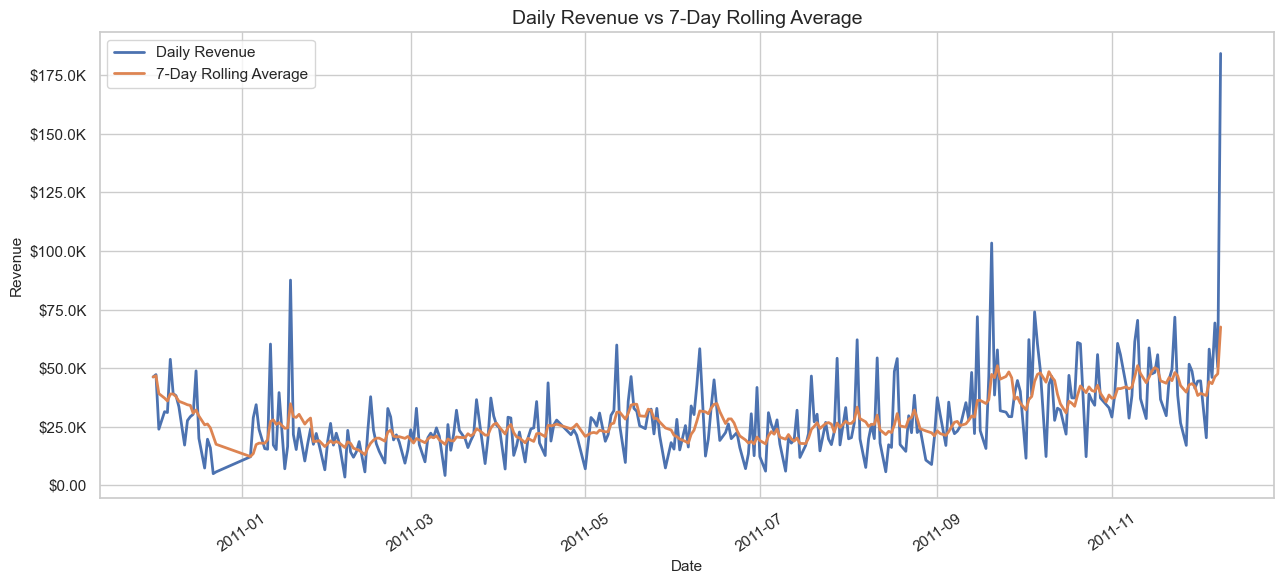

In [9]:
'''
Daily Revenue Visualization
-> Compare daily fluctuation and 7-day rolling average
-> Save the chart output

绘制日收入趋势图
-> 对比日波动和 7 日滚动平均
-> 保存图表文件
'''
daily_chart_path = PLOT_OUTPUT_DIR / 'daily_revenue_vs_7day_rolling_average.png'

fig, ax = plot_line_chart(
    frame=daily_revenue,
    x_col='OrderDay',
    y_cols=['daily_revenue', 'daily_revenue_7d_avg'],
    labels=['Daily Revenue', '7-Day Rolling Average'],
    title='Daily Revenue vs 7-Day Rolling Average',
    y_label='Revenue',
    output_path=daily_chart_path,
)
plt.show()


**Chart insight:** The daily line shows operational volatility, while the 7-day rolling average makes the underlying revenue trend easier to read. This view is useful for spotting whether a sales change is a real trend or just a one-day fluctuation.


/var/folders/sq/_1141z616fzfhq077yl5s5980000gn/T/ipykernel_20737/2419486173.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.05, 0, 1, 1))


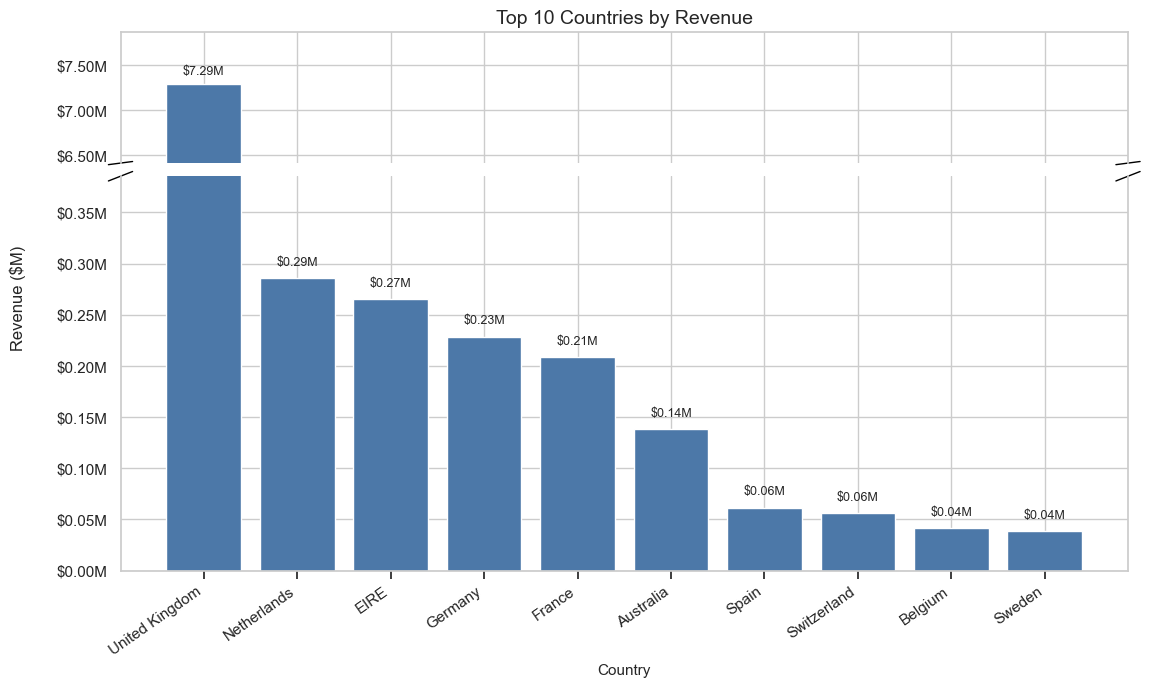

In [10]:

'''
Top Countries Visualization
-> Use broken-axis chart first
-> Label values in $M
-> Save chart with the required filename

绘制 Top 10 国家收入图
-> 优先使用断轴
-> 标注统一 $M
-> 保存同名文件
'''

market_chart_path = PLOT_OUTPUT_DIR / 'top10_countries_by_revenue.png'

try:
    fig, axes = plot_broken_axis_bar_chart(
        frame=top10_countries,
        x_col='Country',
        y_col='country_total_revenue',
        title='Top 10 Countries by Revenue',
        output_path=market_chart_path,
    )
except Exception as error:
    print(f"Broken-axis chart failed, falling back to standard bar chart: {error}")
    fig, ax = plot_bar_chart(
        frame=top10_countries,
        x_col='Country',
        y_col='country_total_revenue',
        title='Top 10 Countries by Revenue',
        x_label='Country',
        y_label='Revenue ($M)',
        output_path=market_chart_path,
    )

plt.show()


**Chart insight:** The Top 10 country chart shows that revenue is not evenly distributed across markets. This helps the business understand where current revenue strength comes from and where diversification may be needed.


## 10. Analytical Log: 3 Business Insights

**Insight 1: Time-Series Trend**  
September 2011 produced the strongest absolute MoM revenue increase, but this should be treated as a growth signal to decompose rather than a final conclusion. The driver summary shows that the month should be checked across order count, AOV, active customers, countries, customer tiers, and products. If the growth is broad-based and repeatable, it can support seasonal promotion planning, inventory preparation, and targeted customer campaigns.

![Monthly Revenue Growth](https://raw.githubusercontent.com/JaxFluxx/Terra-Softech/main/week2/outputs/plots/monthly_revenue_growth_dual_axis.png)

**Insight 2: Customer Value / Repeat Buyer Behavior**  
Repeat buyers account for **65.58%** of customers, and High Value customers contribute about **74.68%** of total revenue. This concentration suggests that loyalty offers, personalized recommendations, early access campaigns, and retention campaigns should focus on high-value and repeat customers first. The next step is to profile these customers by purchase frequency, preferred products, country distribution, active lifespan, and AOV.

![Customer Tier Share](https://raw.githubusercontent.com/JaxFluxx/Terra-Softech/main/week2/outputs/plots/customer_tier_count_and_revenue_share.png)

**Insight 3: Market Concentration**  
The United Kingdom is the core revenue base, but it also creates concentration risk because the business depends heavily on one market. Netherlands, EIRE, Germany, and France are smaller but may offer international expansion opportunities if their revenue comes from stable customers rather than one-off bulk orders. The next analysis should test customer concentration, order stability, and product mix in each international market.

## 11. Supplementary Extension Analysis

This section is kept as a supporting analysis for Insight 1. It briefly checks whether the September 2011 revenue increase was related to order count, customer count, AOV, market contribution, or product contribution.

**Key finding:** September 2011 growth was supported by higher order count, more active customers, and improved AOV. However, the growth still depended heavily on the UK market and a small set of products.

**Limitation:** The dataset does not include marketing campaigns, website traffic, inventory availability, product margin, or acquisition-channel data, so this section can identify likely drivers but cannot fully prove the cause.

Additional output files are saved as `monthly_revenue_driver_summary.csv` and `september_growth_decomposition.csv`.

In [11]:
'''
Extension Analysis
-> Break down monthly revenue growth
-> Focus on 2011-09
-> Identify growth drivers

拓展分析
-> 拆解月度收入增长
-> 聚焦 2011-09
-> 分析增长来源
'''

# 月度 driver summary：收入 = 订单数 x AOV 的简化拆解。
monthly_driver_summary = (
    cleaned_sales
    .groupby('OrderMonth', as_index=False)
    .agg(
        monthly_revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        customer_count=('CustomerID', 'nunique'),
        total_quantity=('Quantity', 'sum'),
    )
    .sort_values('OrderMonth')
    .assign(
        average_order_value=lambda frame: frame['monthly_revenue'] / frame['order_count'],
        revenue_growth=lambda frame: frame['monthly_revenue'].diff(),
        revenue_growth_rate=lambda frame: frame['monthly_revenue'].pct_change(),
        order_count_growth=lambda frame: frame['order_count'].diff(),
        customer_count_growth=lambda frame: frame['customer_count'].diff(),
        aov_growth=lambda frame: frame['average_order_value'].diff(),
        aov_growth_rate=lambda frame: frame['average_order_value'].pct_change(),
    )
)

monthly_driver_display = monthly_driver_summary.assign(
    monthly_revenue_m=monthly_driver_summary['monthly_revenue'].map(format_currency_m),
    revenue_growth_k=monthly_driver_summary['revenue_growth'].map(format_currency_k),
    revenue_growth_rate_display=monthly_driver_summary['revenue_growth_rate'].map(format_signed_percent),
    average_order_value_k=monthly_driver_summary['average_order_value'].map(format_currency_k),
    aov_growth_k=monthly_driver_summary['aov_growth'].map(format_currency_k),
    aov_growth_rate_display=monthly_driver_summary['aov_growth_rate'].map(format_signed_percent),
)

# 给交易明细补上客户层级和首购月份。
customer_segment_lookup = customer_value_segments.assign(
    customer_first_order_month=customer_value_segments['customer_first_order_date'].dt.to_period('M').astype(str)
)[['CustomerID', 'value_tier', 'customer_first_order_month']]

sales_with_segments = cleaned_sales.merge(customer_segment_lookup, on='CustomerID', how='left')
sales_with_segments = sales_with_segments.assign(
    customer_month_status=np.where(
        sales_with_segments['OrderMonth'].eq(sales_with_segments['customer_first_order_month']),
        'New Customer',
        'Returning Customer',
    )
)

september_sales = sales_with_segments.loc[sales_with_segments['OrderMonth'].eq('2011-09')]
september_total_revenue = september_sales['Revenue'].sum()

# 2011-09 按国家拆解。
september_by_country = (
    september_sales
    .groupby('Country', as_index=False)
    .agg(
        revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        customer_count=('CustomerID', 'nunique'),
    )
    .assign(
        decomposition_view='Country',
        dimension_value=lambda frame: frame['Country'],
        revenue_share=lambda frame: frame['revenue'] / september_total_revenue,
        quantity=np.nan,
        stock_code='',
        description='',
    )
    .sort_values('revenue', ascending=False)
)

# 2011-09 按客户层级拆解。
september_by_tier = (
    september_sales
    .groupby('value_tier', as_index=False)
    .agg(
        revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        customer_count=('CustomerID', 'nunique'),
    )
    .assign(
        decomposition_view='Customer Tier',
        dimension_value=lambda frame: frame['value_tier'],
        revenue_share=lambda frame: frame['revenue'] / september_total_revenue,
        quantity=np.nan,
        stock_code='',
        description='',
    )
    .sort_values('revenue', ascending=False)
)

# 2011-09 按新老客户拆解。
september_by_customer_status = (
    september_sales
    .groupby('customer_month_status', as_index=False)
    .agg(
        revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        customer_count=('CustomerID', 'nunique'),
    )
    .assign(
        decomposition_view='Customer Status',
        dimension_value=lambda frame: frame['customer_month_status'],
        revenue_share=lambda frame: frame['revenue'] / september_total_revenue,
        quantity=np.nan,
        stock_code='',
        description='',
    )
    .sort_values('revenue', ascending=False)
)

# 2011-09 Top products 拆解。
september_by_product = (
    september_sales
    .groupby(['StockCode', 'Description'], as_index=False)
    .agg(
        revenue=('Revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
        customer_count=('CustomerID', 'nunique'),
        quantity=('Quantity', 'sum'),
    )
    .assign(
        decomposition_view='Top Product',
        dimension_value=lambda frame: frame['Description'],
        revenue_share=lambda frame: frame['revenue'] / september_total_revenue,
        stock_code=lambda frame: frame['StockCode'],
        description=lambda frame: frame['Description'],
    )
    .sort_values('revenue', ascending=False)
    .head(10)
)

# 合并成一个输出表，方便上传或后续报告引用。
september_growth_decomposition = pd.concat(
    [
        september_by_country.head(10),
        september_by_tier,
        september_by_customer_status,
        september_by_product,
    ],
    ignore_index=True,
    sort=False,
)[[
    'decomposition_view',
    'dimension_value',
    'revenue',
    'revenue_share',
    'order_count',
    'customer_count',
    'quantity',
    'stock_code',
    'description',
]]

monthly_driver_focus_display = monthly_driver_display.loc[
    monthly_driver_display['OrderMonth'].isin(['2011-08', '2011-09'])
][[
    'OrderMonth',
    'monthly_revenue_m',
    'revenue_growth_k',
    'revenue_growth_rate_display',
    'order_count',
    'order_count_growth',
    'customer_count',
    'customer_count_growth',
    'average_order_value_k',
    'aov_growth_k',
    'aov_growth_rate_display',
]]

september_country_display = september_by_country.head(5).assign(
    revenue_m=september_by_country.head(5)['revenue'].map(format_currency_m),
    revenue_share=september_by_country.head(5)['revenue_share'].map(lambda x: f'{x:.1%}'),
)[['Country', 'revenue_m', 'revenue_share', 'order_count', 'customer_count']]

september_segment_display = pd.concat(
    [september_by_tier, september_by_customer_status],
    ignore_index=True,
    sort=False,
).assign(
    revenue_m=lambda frame: frame['revenue'].map(format_currency_m),
    revenue_share=lambda frame: frame['revenue_share'].map(lambda x: f'{x:.1%}'),
)[['decomposition_view', 'dimension_value', 'revenue_m', 'revenue_share', 'order_count', 'customer_count']]

september_product_display = september_by_product.head(5).assign(
    revenue_m=september_by_product.head(5)['revenue'].map(format_currency_m),
    revenue_share=september_by_product.head(5)['revenue_share'].map(lambda x: f'{x:.1%}'),
)[['StockCode', 'Description', 'revenue_m', 'revenue_share', 'order_count', 'quantity']]

display(monthly_driver_focus_display)
display(september_country_display)
display(september_segment_display)
display(september_product_display)

print(
    "Extension interpretation: September growth came with higher order count, more active customers, and higher AOV. "
    "This suggests the growth was not only a price or basket-size effect; it should be decomposed further by market, customer tier, and product before planning seasonal campaigns."
)

# 输出拓展分析结果。
monthly_driver_summary.to_csv(FORM_OUTPUT_DIR / 'monthly_revenue_driver_summary.csv', index=False)
september_growth_decomposition.to_csv(FORM_OUTPUT_DIR / 'september_growth_decomposition.csv', index=False)


,OrderMonth,monthly_revenue_m,revenue_growth_k,revenue_growth_rate_display,order_count,order_count_growth,customer_count,customer_count_growth,average_order_value_k,aov_growth_k,aov_growth_rate_display
8,2011-08,$0.64M,$45.09K,+7.5%,1280,-51.00,935,-14.00,$0.50K,$0.05K,+11.8%
9,2011-09,$0.95M,$306.64K,+47.6%,1755,475.00,1266,331.00,$0.54K,$0.04K,+7.7%


,Country,revenue_m,revenue_share,order_count,customer_count
19,United Kingdom,$0.79M,83.6%,1568,1146
5,EIRE,$0.04M,4.3%,36,2
11,Netherlands,$0.03M,2.8%,7,2
7,France,$0.02M,2.5%,45,36
8,Germany,$0.02M,1.9%,41,31


,decomposition_view,dimension_value,revenue_m,revenue_share,order_count,customer_count
0,Customer Tier,High Value,$0.68M,71.9%,926,526
1,Customer Tier,Medium Value,$0.25M,25.8%,702,615
2,Customer Tier,Low Value,$0.02M,2.3%,127,125
3,Customer Status,Returning Customer,$0.80M,83.7%,1419,967
4,Customer Status,New Customer,$0.15M,16.3%,336,299


,StockCode,Description,revenue_m,revenue_share,order_count,quantity
1740,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,$0.01M,1.0%,71,2056
993,22423,REGENCY CAKESTAND 3 TIER,$0.01M,0.9%,134,730
2410,85099B,JUMBO BAG RED RETROSPOT,$0.01M,0.8%,183,4175
2419,85123A,WHITE HANGING HEART T-LIGHT HOLDER,$0.01M,0.7%,154,2440
1847,23355,HOT WATER BOTTLE KEEP CALM,$0.01M,0.6%,190,1314


Extension interpretation: September growth came with higher order count, more active customers, and higher AOV. This suggests the growth was not only a price or basket-size effect; it should be decomposed further by market, customer tier, and product before planning seasonal campaigns.


## 12. Engineering Notes & Optimization Summary

- `CustomerID` and `InvoiceNo` are loaded as strings because they are identifiers.
- `OrderDate` is parsed once during CSV loading because CSV files do not preserve datetime types.
- The notebook uses vectorized `groupby`, `agg`, `assign`, `merge`, `pivot_table`, `pct_change`, and `rolling` operations.
- No unnecessary deep-copy operations are used on the large transaction table.
- Reusable helper functions handle currency formatting, signed growth-rate formatting, MoM growth, and chart styling.
- The Top 10 countries chart uses a broken axis to keep the UK visible while making smaller countries easier to compare.
- Week 1 source files are read-only in this notebook; Week 2 outputs are saved under `outputs/forms/` and `outputs/plots/`.